In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

df = pd.read_csv("../data/alzheimers_disease_data.csv")

In [3]:
X = df.drop(columns=["Diagnosis", "DoctorInCharge"])
y = df["Diagnosis"]
print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (2149, 33)
Target Shape: (2149,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Labels:", y_train.shape)
print("Testing Labels:", y_test.shape)

Training Features: (1719, 33)
Testing Features: (430, 33)
Training Labels: (1719,)
Testing Labels: (430,)


In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Training Data Shape", X_train_scaled.shape)
print("Testing Data Shape", X_test_scaled.shape)

Training Data Shape (1719, 33)
Testing Data Shape (430, 33)


In [6]:
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)
print("Model training completed.")

Model training completed.


In [7]:
y_pred = model.predict(X_test_scaled)
print("First 10 Predictions:")
print(y_pred[:10])
print("\n First 10 Actual Values:")
print(y_test.values[:10])

First 10 Predictions:
[0 0 0 0 0 0 1 0 0 1]

 First 10 Actual Values:
[0 0 0 0 0 0 1 0 0 1]


In [8]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")
print(f"Model Accuracy: {accuracy*100:.2f}%")


Model Accuracy: 0.8256
Model Accuracy: 82.56%


In [9]:
from sklearn.metrics import classification_report
classification_report(y_test, y_pred)

'              precision    recall  f1-score   support\n\n           0       0.85      0.89      0.87       277\n           1       0.78      0.71      0.74       153\n\n    accuracy                           0.83       430\n   macro avg       0.81      0.80      0.81       430\nweighted avg       0.82      0.83      0.82       430\n'

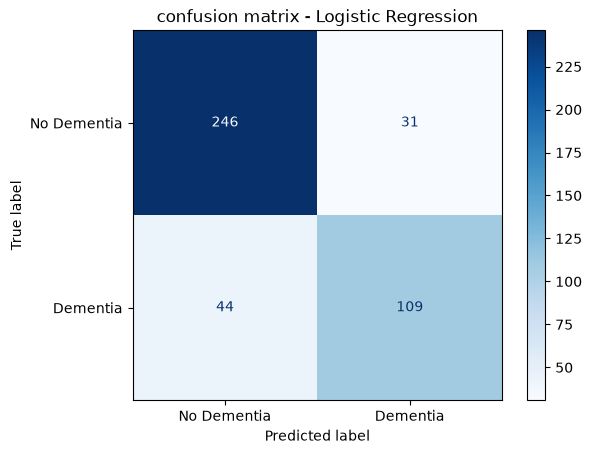

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Dementia", "Dementia"])
disp.plot(cmap="Blues")
plt.title("confusion matrix - Logistic Regression")
plt.show()

In [11]:
print(X_train.columns.tolist())

['PatientID', 'Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion', 'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness']
